In [1]:
# ============================================================
# Phase 1: Data Loading, Merging & EDA
# Solar Power Output Prediction
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── 0. Plot styling ──────────────────────────────────────────
sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (12, 5)

# ============================================================
# 1. LOAD DATA
# ============================================================
gen = pd.read_csv("Plant_1_Generation_Data.csv")
weather = pd.read_csv("Plant_1_Weather_Sensor_Data.csv")

print("Generation shape:", gen.shape)
print("Weather shape   :", weather.shape)
print("\nGeneration columns:", gen.columns.tolist())
print("Weather columns   :", weather.columns.tolist())

Generation shape: (68778, 7)
Weather shape   : (3182, 6)

Generation columns: ['DATE_TIME', 'PLANT_ID', 'SOURCE_KEY', 'DC_POWER', 'AC_POWER', 'DAILY_YIELD', 'TOTAL_YIELD']
Weather columns   : ['DATE_TIME', 'PLANT_ID', 'SOURCE_KEY', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']


In [3]:
# ============================================================
# 2. PARSE DATETIME & MERGE
# ============================================================
gen["DATE_TIME"]     = pd.to_datetime(gen["DATE_TIME"],     dayfirst=True)
weather["DATE_TIME"] = pd.to_datetime(weather["DATE_TIME"], dayfirst=True)

# Aggregate generation across all inverters per timestamp
# (weather sensor gives one reading per timestamp)
gen_agg = gen.groupby("DATE_TIME").agg(
    DC_POWER    = ("DC_POWER",    "sum"),
    AC_POWER    = ("AC_POWER",    "sum"),
    DAILY_YIELD = ("DAILY_YIELD", "mean"),
    TOTAL_YIELD = ("TOTAL_YIELD", "mean")
).reset_index()

# Merge on DATE_TIME
df = pd.merge(gen_agg, weather[["DATE_TIME","AMBIENT_TEMPERATURE",
                                 "MODULE_TEMPERATURE","IRRADIATION"]],
              on="DATE_TIME", how="inner")

print("\nMerged dataframe shape:", df.shape)
df.head()


Merged dataframe shape: (3157, 8)


C:\Users\chysu\AppData\Local\Temp\ipykernel_14916\1791177155.py:5: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  weather["DATE_TIME"] = pd.to_datetime(weather["DATE_TIME"], dayfirst=True)


,DATE_TIME,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,0.0,0.0,0.0,6.837223e+06,25.184316,22.857507,0.0
1,2020-05-15 00:15:00,0.0,0.0,0.0,6.837223e+06,25.084589,22.761668,0.0
2,2020-05-15 00:30:00,0.0,0.0,0.0,6.837223e+06,24.935753,22.592306,0.0
3,2020-05-15 00:45:00,0.0,0.0,0.0,6.837223e+06,24.846130,22.360852,0.0
4,2020-05-15 01:00:00,0.0,0.0,0.0,6.852802e+06,24.621525,22.165423,0.0


In [5]:
# ============================================================
# 3. BASIC CHECKS
# ============================================================
print("=== Data Types ===")
print(df.dtypes)

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Basic Statistics ===")
print(df.describe().round(2))

=== Data Types ===
DATE_TIME              datetime64[ns]
DC_POWER                      float64
AC_POWER                      float64
DAILY_YIELD                   float64
TOTAL_YIELD                   float64
AMBIENT_TEMPERATURE           float64
MODULE_TEMPERATURE            float64
IRRADIATION                   float64
dtype: object

=== Missing Values ===
DATE_TIME              0
DC_POWER               0
AC_POWER               0
DAILY_YIELD            0
TOTAL_YIELD            0
AMBIENT_TEMPERATURE    0
MODULE_TEMPERATURE     0
IRRADIATION            0
dtype: int64

=== Basic Statistics ===
                           DATE_TIME   DC_POWER  AC_POWER  DAILY_YIELD  \
count                           3157    3157.00   3157.00      3157.00   
mean   2020-06-01 06:41:41.298701568   68560.02   6704.83      3324.40   
min              2020-05-15 00:00:00       0.00      0.00         0.00   
25%              2020-05-23 23:15:00       0.00      0.00         4.12   
50%              2020-06-01 12

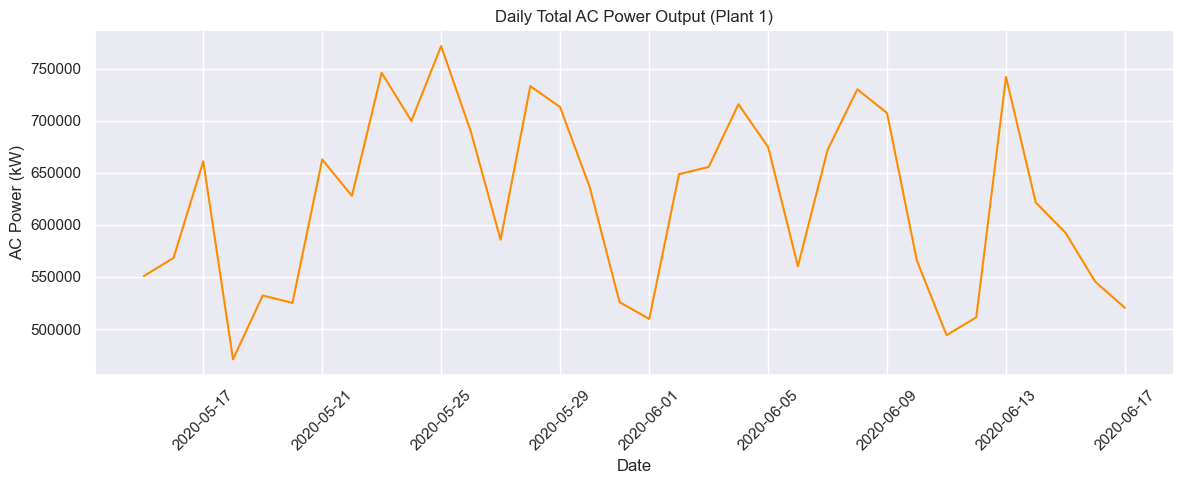

In [6]:
# ============================================================
# 4. PLOT 1 — Time-Series: Daily AC Power Output
# ============================================================
daily = df.groupby(df["DATE_TIME"].dt.date)["AC_POWER"].sum()

plt.figure()
plt.plot(daily.index, daily.values, color="darkorange", linewidth=1.5)
plt.title("Daily Total AC Power Output (Plant 1)")
plt.xlabel("Date")
plt.ylabel("AC Power (kW)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("01_daily_ac_power.png", dpi=150)
plt.show()

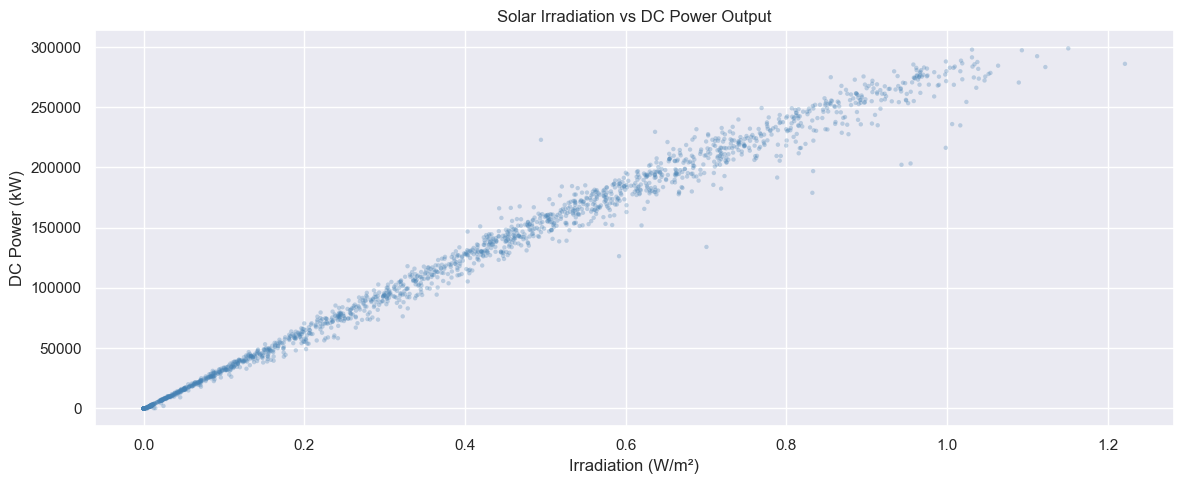

In [7]:
# ============================================================
# 5. PLOT 2 — Scatter: Irradiation vs DC Power
# ============================================================
plt.figure()
plt.scatter(df["IRRADIATION"], df["DC_POWER"],
            alpha=0.3, color="steelblue", edgecolors="none", s=10)
plt.title("Solar Irradiation vs DC Power Output")
plt.xlabel("Irradiation (W/m²)")
plt.ylabel("DC Power (kW)")
plt.tight_layout()
plt.savefig("02_irradiation_vs_dc.png", dpi=150)
plt.show()

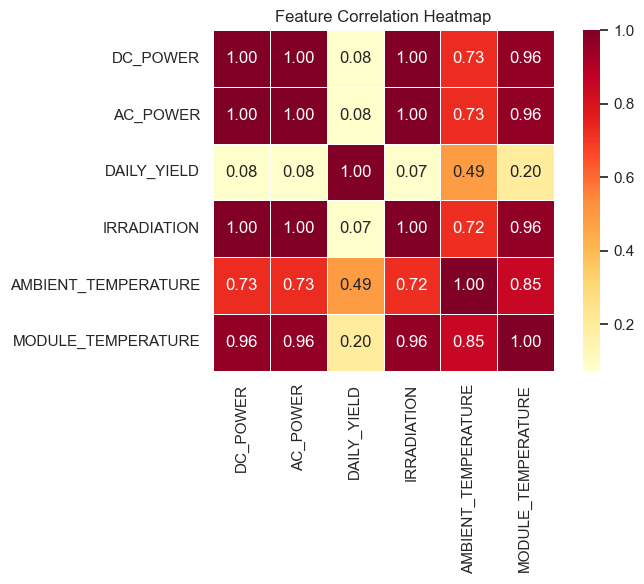

In [8]:
# ============================================================
# 6. PLOT 3 — Correlation Heatmap
# ============================================================
corr_cols = ["DC_POWER","AC_POWER","DAILY_YIELD",
             "IRRADIATION","AMBIENT_TEMPERATURE","MODULE_TEMPERATURE"]

plt.figure(figsize=(8, 6))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt=".2f",
            cmap="YlOrRd", square=True, linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig("03_correlation_heatmap.png", dpi=150)
plt.show()

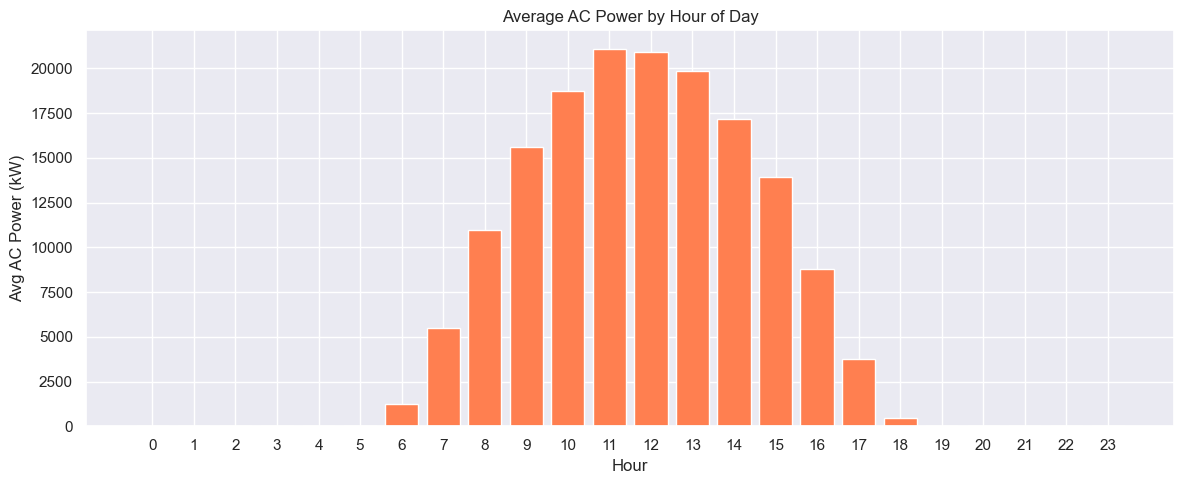

In [9]:
# ============================================================
# 7. PLOT 4 — Hourly Average AC Power (daily pattern)
# ============================================================
df["HOUR"] = df["DATE_TIME"].dt.hour
hourly_avg = df.groupby("HOUR")["AC_POWER"].mean()

plt.figure()
plt.bar(hourly_avg.index, hourly_avg.values, color="coral", edgecolor="white")
plt.title("Average AC Power by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Avg AC Power (kW)")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.savefig("04_hourly_pattern.png", dpi=150)
plt.show()

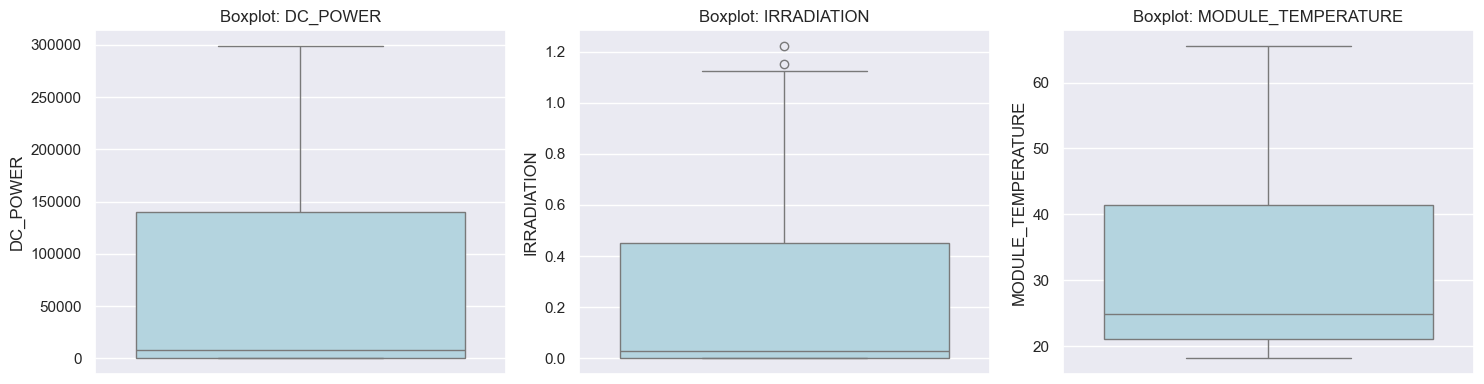

In [10]:
# ============================================================
# 8. OUTLIER CHECK — Boxplots
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["DC_POWER", "IRRADIATION", "MODULE_TEMPERATURE"]):
    sns.boxplot(y=df[col], ax=ax, color="lightblue")
    ax.set_title(f"Boxplot: {col}")
plt.tight_layout()
plt.savefig("05_boxplots.png", dpi=150)
plt.show()

In [11]:
# ============================================================
# 9. SAVE CLEANED DATA FOR PHASE 2
# ============================================================
df.to_csv("plant1_merged_eda.csv", index=False)
print("Saved: plant1_merged_eda.csv")
print("Shape:", df.shape)

Saved: plant1_merged_eda.csv
Shape: (3157, 9)


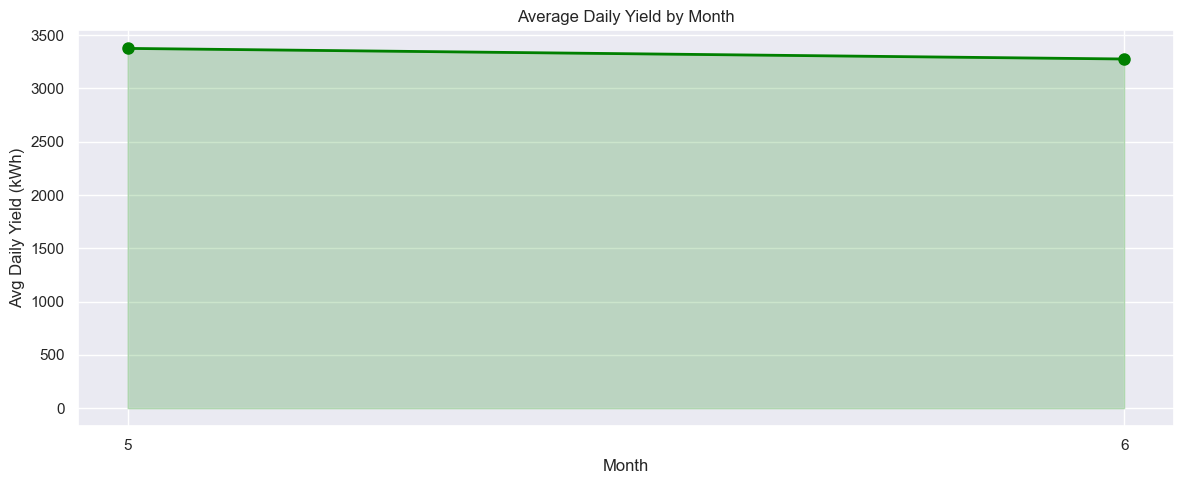

In [12]:
# ============================================================
# PLOT 6 — Monthly Energy Yield Trend
# ============================================================
df["MONTH"] = df["DATE_TIME"].dt.month
df["DATE"]  = df["DATE_TIME"].dt.date

monthly_yield = df.groupby("MONTH")["DAILY_YIELD"].mean()

plt.figure()
plt.plot(monthly_yield.index, monthly_yield.values, 
         marker="o", color="green", linewidth=2, markersize=8)
plt.fill_between(monthly_yield.index, monthly_yield.values, alpha=0.2, color="green")
plt.title("Average Daily Yield by Month")
plt.xlabel("Month")
plt.ylabel("Avg Daily Yield (kWh)")
plt.xticks(monthly_yield.index)
plt.tight_layout()
plt.savefig("06_monthly_yield_trend.png", dpi=150)
plt.show()

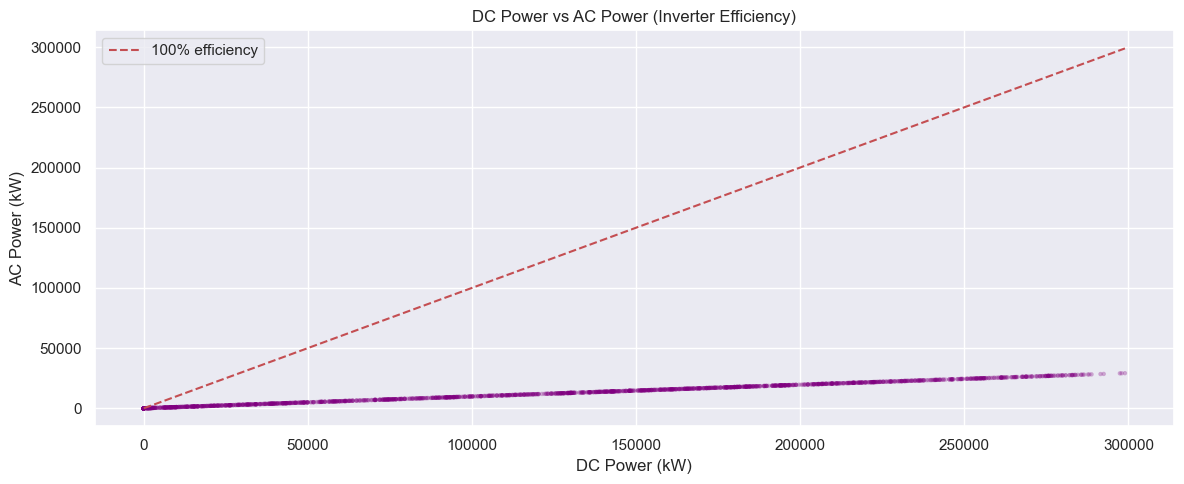

In [13]:
# ============================================================
# PLOT 7 — DC Power vs AC Power (Inverter Efficiency Check)
# ============================================================
plt.figure()
plt.scatter(df["DC_POWER"], df["AC_POWER"],
            alpha=0.3, s=10, color="purple", edgecolors="none")

# Perfect efficiency reference line
max_val = df["DC_POWER"].max()
plt.plot([0, max_val], [0, max_val], "r--", linewidth=1.5, label="100% efficiency")

plt.title("DC Power vs AC Power (Inverter Efficiency)")
plt.xlabel("DC Power (kW)")
plt.ylabel("AC Power (kW)")
plt.legend()
plt.tight_layout()
plt.savefig("07_dc_vs_ac_efficiency.png", dpi=150)
plt.show()

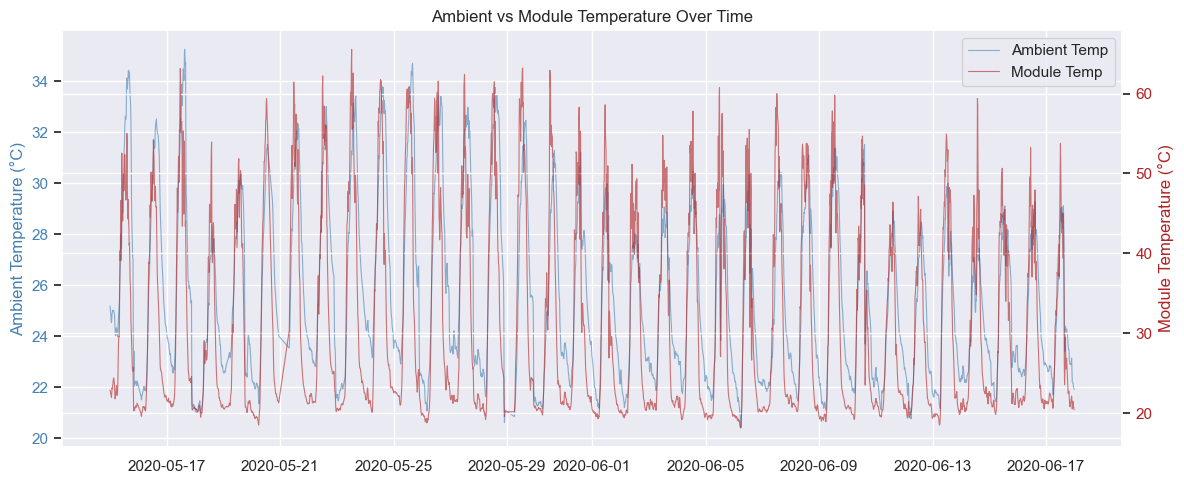

In [15]:
# ============================================================
# PLOT 8 — Ambient vs Module Temperature over Time
# ============================================================
fig, ax1 = plt.subplots()

ax1.plot(df["DATE_TIME"], df["AMBIENT_TEMPERATURE"],
         color="steelblue", alpha=0.6, linewidth=0.8, label="Ambient Temp")
ax1.set_ylabel("Ambient Temperature (°C)", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")

ax2 = ax1.twinx()
ax2.plot(df["DATE_TIME"], df["MODULE_TEMPERATURE"],
         color="firebrick", alpha=0.6, linewidth=0.8, label="Module Temp")
ax2.set_ylabel("Module Temperature (°C)", color="firebrick")
ax2.tick_params(axis="y", labelcolor="firebrick")

plt.title("Ambient vs Module Temperature Over Time")
fig.legend(loc="upper right", bbox_to_anchor=(1, 1), bbox_transform=ax1.transAxes)
plt.tight_layout()
plt.savefig("08_temperature_comparison.png", dpi=150)
plt.show()

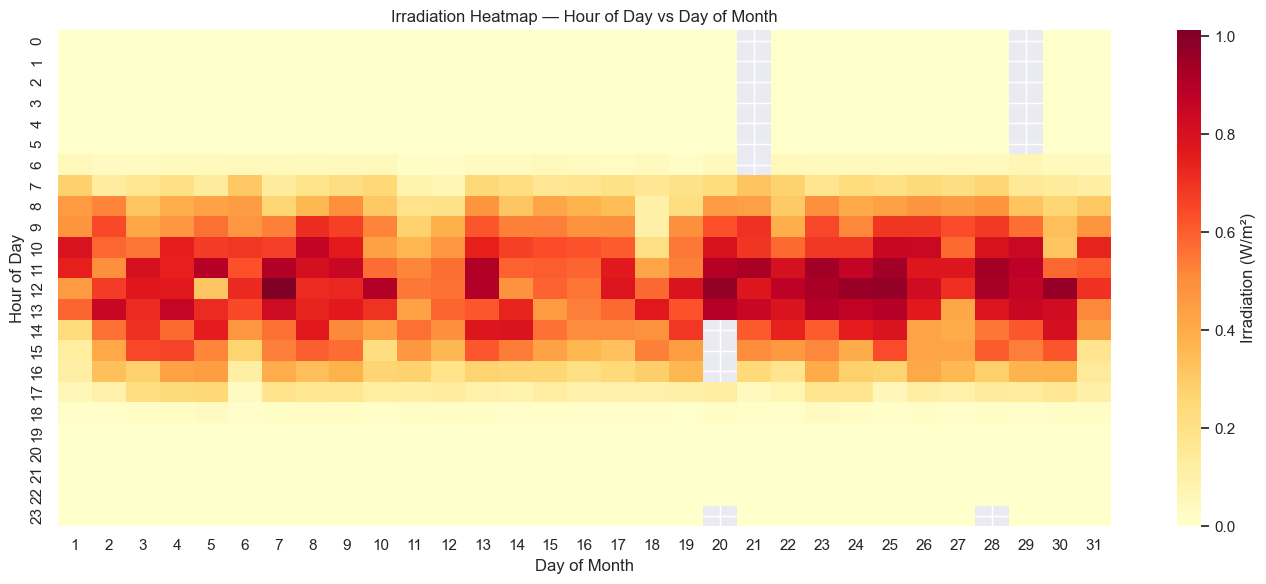

In [16]:
# ============================================================
# PLOT 9 — Irradiation Heatmap (Hour vs Date)
# ============================================================
df["DAY"] = df["DATE_TIME"].dt.day

# Pivot: rows = hour, cols = date
irr_pivot = df.pivot_table(values="IRRADIATION",
                            index="HOUR", columns="DAY", aggfunc="mean")

plt.figure(figsize=(14, 6))
sns.heatmap(irr_pivot, cmap="YlOrRd", linewidths=0,
            cbar_kws={"label": "Irradiation (W/m²)"})
plt.title("Irradiation Heatmap — Hour of Day vs Day of Month")
plt.xlabel("Day of Month")
plt.ylabel("Hour of Day")
plt.tight_layout()
plt.savefig("09_irradiation_heatmap.png", dpi=150)
plt.show()


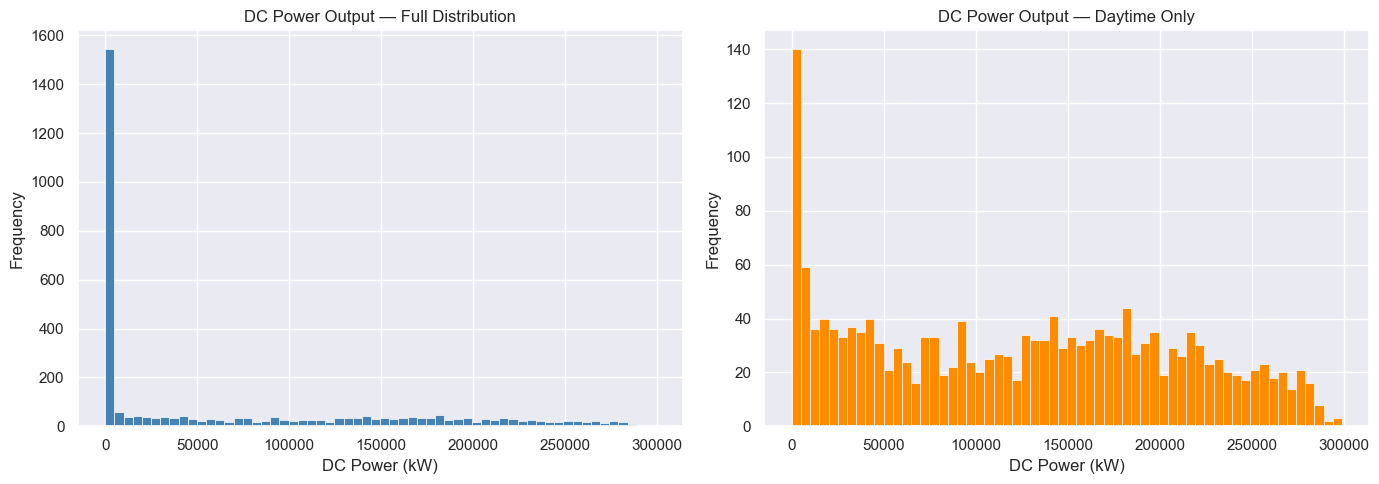

In [17]:
# ============================================================
# PLOT 10 — Distribution of DC Power Output
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full distribution
axes[0].hist(df["DC_POWER"], bins=60, color="steelblue",
             edgecolor="white", linewidth=0.5)
axes[0].set_title("DC Power Output — Full Distribution")
axes[0].set_xlabel("DC Power (kW)")
axes[0].set_ylabel("Frequency")

# Daytime only (filter out zero/nighttime readings)
daytime = df[df["IRRADIATION"] > 0]
axes[1].hist(daytime["DC_POWER"], bins=60, color="darkorange",
             edgecolor="white", linewidth=0.5)
axes[1].set_title("DC Power Output — Daytime Only")
axes[1].set_xlabel("DC Power (kW)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.savefig("10_dc_power_distribution.png", dpi=150)
plt.show()

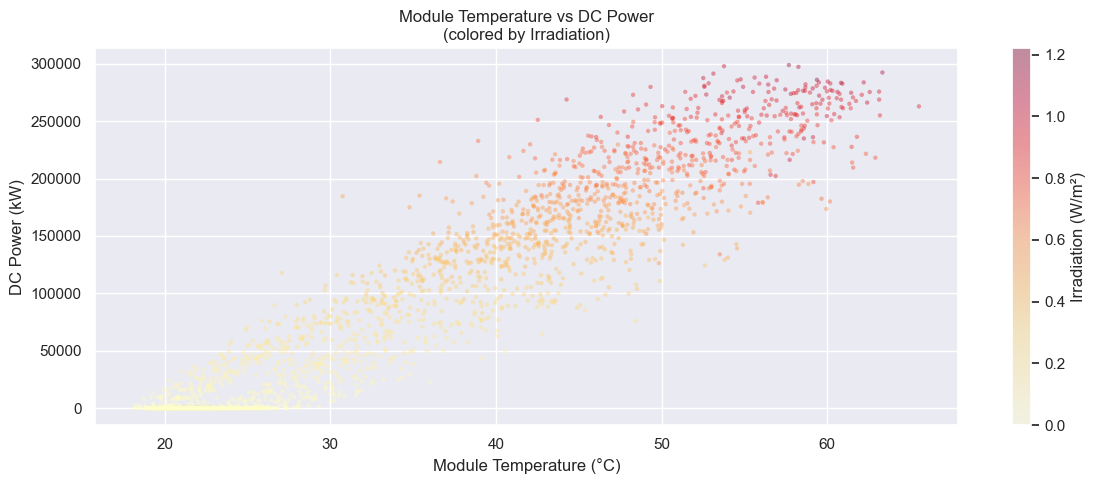

In [18]:
# ============================================================
# PLOT 11 — Module Temperature vs DC Power
#           (shows thermal performance degradation)
# ============================================================
plt.figure()
sc = plt.scatter(df["MODULE_TEMPERATURE"], df["DC_POWER"],
                 c=df["IRRADIATION"], cmap="YlOrRd",
                 alpha=0.4, s=10, edgecolors="none")
plt.colorbar(sc, label="Irradiation (W/m²)")
plt.title("Module Temperature vs DC Power\n(colored by Irradiation)")
plt.xlabel("Module Temperature (°C)")
plt.ylabel("DC Power (kW)")
plt.tight_layout()
plt.savefig("11_temp_vs_power_irradiation.png", dpi=150)
plt.show()

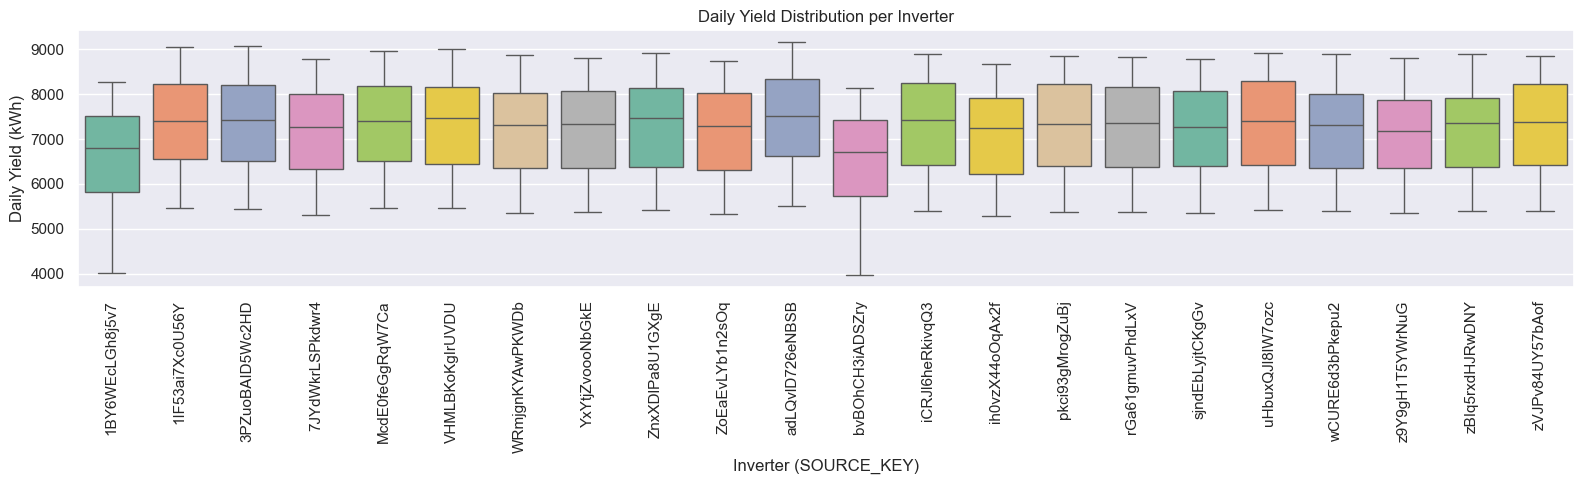

In [20]:
# ============================================================
# PLOT 12 — Per-Inverter Daily Yield Comparison (Box Plot)
# ============================================================
inv_daily = gen.groupby(["SOURCE_KEY", gen["DATE_TIME"].dt.date])["DAILY_YIELD"].max().reset_index()

plt.figure(figsize=(16, 5))
sns.boxplot(data=inv_daily, x="SOURCE_KEY", y="DAILY_YIELD",
            hue="SOURCE_KEY", legend=False,         
            palette="Set2", flierprops={"marker": ".", "markersize": 3})
plt.title("Daily Yield Distribution per Inverter")
plt.xlabel("Inverter (SOURCE_KEY)")
plt.ylabel("Daily Yield (kWh)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("12_per_inverter_yield.png", dpi=150)
plt.show()

In [21]:
# ============================================================
# Phase 2: Preprocessing & Feature Engineering
# ============================================================

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# 1. LOAD MERGED DATA FROM PHASE 1
# ============================================================
df = pd.read_csv("plant1_merged_eda.csv", parse_dates=["DATE_TIME"])
print("Loaded shape:", df.shape)
df.head()

Loaded shape: (3157, 9)


,DATE_TIME,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,HOUR
0,2020-05-15 00:00:00,0.0,0.0,0.0,6.837223e+06,25.184316,22.857507,0.0,0
1,2020-05-15 00:15:00,0.0,0.0,0.0,6.837223e+06,25.084589,22.761668,0.0,0
2,2020-05-15 00:30:00,0.0,0.0,0.0,6.837223e+06,24.935753,22.592306,0.0,0
3,2020-05-15 00:45:00,0.0,0.0,0.0,6.837223e+06,24.846130,22.360852,0.0,0
4,2020-05-15 01:00:00,0.0,0.0,0.0,6.852802e+06,24.621525,22.165423,0.0,1


In [22]:
# ============================================================
# 2. HANDLE MISSING VALUES
# ============================================================
print("Missing values before:\n", df.isnull().sum())

# Forward fill for small gaps in time-series (sensor dropouts)
df = df.sort_values("DATE_TIME").reset_index(drop=True)
df.ffill(inplace=True)

print("\nMissing values after:\n", df.isnull().sum())

Missing values before:
 DATE_TIME              0
DC_POWER               0
AC_POWER               0
DAILY_YIELD            0
TOTAL_YIELD            0
AMBIENT_TEMPERATURE    0
MODULE_TEMPERATURE     0
IRRADIATION            0
HOUR                   0
dtype: int64

Missing values after:
 DATE_TIME              0
DC_POWER               0
AC_POWER               0
DAILY_YIELD            0
TOTAL_YIELD            0
AMBIENT_TEMPERATURE    0
MODULE_TEMPERATURE     0
IRRADIATION            0
HOUR                   0
dtype: int64


In [23]:
# ============================================================
# 3. REMOVE NIGHTTIME ROWS
# ============================================================
# Night rows (irradiation = 0) add noise to the model
# Keep only daytime readings

before = len(df)
df = df[df["IRRADIATION"] > 0].reset_index(drop=True)
after = len(df)

print(f"Removed {before - after} nighttime rows")
print(f"Remaining rows: {after}")

Removed 1403 nighttime rows
Remaining rows: 1754


In [24]:
# ============================================================
# 4. REMOVE DUPLICATES
# ============================================================
dupes = df.duplicated(subset="DATE_TIME").sum()
print(f"Duplicate timestamps: {dupes}")
df.drop_duplicates(subset="DATE_TIME", inplace=True)
df.reset_index(drop=True, inplace=True)

Duplicate timestamps: 0


In [25]:
# ============================================================
# 5. FEATURE ENGINEERING
# ============================================================

# ── Time features ──────────────────────────────────────────
df["HOUR"]        = df["DATE_TIME"].dt.hour
df["MINUTE"]      = df["DATE_TIME"].dt.minute
df["DAY_OF_WEEK"] = df["DATE_TIME"].dt.dayofweek   # 0=Mon, 6=Sun
df["MONTH"]       = df["DATE_TIME"].dt.month
df["DAY_OF_YEAR"] = df["DATE_TIME"].dt.dayofyear

# ── Cyclical encoding for hour (captures 23→0 continuity) ──
df["HOUR_SIN"] = np.sin(2 * np.pi * df["HOUR"] / 24)
df["HOUR_COS"] = np.cos(2 * np.pi * df["HOUR"] / 24)

# ── Physics-based features ─────────────────────────────────
# Irradiation to temperature ratio — affects panel efficiency
df["IRR_TEMP_RATIO"] = df["IRRADIATION"] / (df["MODULE_TEMPERATURE"] + 1)

# Temperature delta — how much hotter panel is vs ambient
df["TEMP_DELTA"] = df["MODULE_TEMPERATURE"] - df["AMBIENT_TEMPERATURE"]

# ── Lag features (previous timestep output) ────────────────
df["DC_POWER_LAG1"] = df["DC_POWER"].shift(1)   # 15 min ago
df["DC_POWER_LAG2"] = df["DC_POWER"].shift(2)   # 30 min ago
df["IRR_LAG1"]      = df["IRRADIATION"].shift(1)

# Drop rows with NaN from lag
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print("Shape after feature engineering:", df.shape)
print("\nNew columns added:")
print([c for c in df.columns if c not in 
       ["DATE_TIME","DC_POWER","AC_POWER","DAILY_YIELD",
        "TOTAL_YIELD","IRRADIATION","AMBIENT_TEMPERATURE","MODULE_TEMPERATURE"]])

Shape after feature engineering: (1752, 20)

New columns added:
['HOUR', 'MINUTE', 'DAY_OF_WEEK', 'MONTH', 'DAY_OF_YEAR', 'HOUR_SIN', 'HOUR_COS', 'IRR_TEMP_RATIO', 'TEMP_DELTA', 'DC_POWER_LAG1', 'DC_POWER_LAG2', 'IRR_LAG1']


In [26]:
# ============================================================
# 6. OUTLIER REMOVAL (IQR method on DC_POWER)
# ============================================================
Q1 = df["DC_POWER"].quantile(0.25)
Q3 = df["DC_POWER"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

before = len(df)
df = df[(df["DC_POWER"] >= lower) & (df["DC_POWER"] <= upper)]
print(f"Outliers removed: {before - len(df)}")
print(f"Remaining rows: {len(df)}")

Outliers removed: 0
Remaining rows: 1752


In [27]:
# ============================================================
# 7. DEFINE FEATURES & TARGET
# ============================================================
TARGET = "AC_POWER"   # What we want to predict

FEATURES = [
    "IRRADIATION",
    "AMBIENT_TEMPERATURE",
    "MODULE_TEMPERATURE",
    "IRR_TEMP_RATIO",
    "TEMP_DELTA",
    "HOUR_SIN",
    "HOUR_COS",
    "DAY_OF_YEAR",
    "DC_POWER_LAG1",
    "DC_POWER_LAG2",
    "IRR_LAG1"
]

X = df[FEATURES]
y = df[TARGET]

print("Features:", FEATURES)
print("Target  :", TARGET)
print("X shape :", X.shape)
print("y shape :", y.shape)

Features: ['IRRADIATION', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRR_TEMP_RATIO', 'TEMP_DELTA', 'HOUR_SIN', 'HOUR_COS', 'DAY_OF_YEAR', 'DC_POWER_LAG1', 'DC_POWER_LAG2', 'IRR_LAG1']
Target  : AC_POWER
X shape : (1752, 11)
y shape : (1752,)


In [28]:
# ============================================================
# 8. TIME-BASED TRAIN / TEST SPLIT
# ============================================================
# IMPORTANT: Never use random split for time-series!
# Use last 20% of time as test set

split_idx = int(len(df) * 0.80)

X_train = X.iloc[:split_idx]
X_test  = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test  = y.iloc[split_idx:]

print(f"Train size: {len(X_train)} rows")
print(f"Test size : {len(X_test)} rows")
print(f"Train period: {df['DATE_TIME'].iloc[0]} → {df['DATE_TIME'].iloc[split_idx]}")
print(f"Test period : {df['DATE_TIME'].iloc[split_idx]} → {df['DATE_TIME'].iloc[-1]}")

Train size: 1401 rows
Test size : 351 rows
Train period: 2020-05-15 06:15:00 → 2020-06-11 10:15:00
Test period : 2020-06-11 10:15:00 → 2020-06-17 18:45:00


In [29]:
# ============================================================
# 9. FEATURE SCALING
# ============================================================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   # fit ONLY on train
X_test_scaled  = scaler.transform(X_test)         # transform test

print("Scaling done.")
print("Mean (train):", scaler.mean_.round(2))

Scaling done.
Mean (train): [ 4.3000000e-01  2.7790000e+01  3.9820000e+01  1.0000000e-02
  1.2030000e+01  3.0000000e-02 -5.7000000e-01  1.4935000e+02
  1.2567385e+05  1.2559897e+05  4.3000000e-01]


In [30]:
# ============================================================
# 10. SAVE PROCESSED DATA FOR PHASE 3
# ============================================================
import joblib

# Save processed dataframe
df.to_csv("plant1_processed.csv", index=False)

# Save scaler for later use in prediction
joblib.dump(scaler, "scaler.pkl")

print("Saved: plant1_processed.csv")
print("Saved: scaler.pkl")
print("\nFinal shape:", df.shape)
df[FEATURES + [TARGET]].head()

Saved: plant1_processed.csv
Saved: scaler.pkl

Final shape: (1752, 20)


,IRRADIATION,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRR_TEMP_RATIO,TEMP_DELTA,HOUR_SIN,HOUR_COS,DAY_OF_YEAR,DC_POWER_LAG1,DC_POWER_LAG2,IRR_LAG1,AC_POWER
0,0.022282,24.011635,22.353459,0.000954,-1.658177,1.000000,6.123234e-17,136,942.148810,0.000000,0.005887,593.338690
1,0.049410,23.976731,22.893282,0.002068,-1.083449,1.000000,6.123234e-17,136,6142.101190,942.148810,0.022282,1480.194643
2,0.095394,24.218990,24.442444,0.003749,0.223454,1.000000,6.123234e-17,136,15271.154762,6142.101190,0.049410,2790.448214
3,0.141940,24.537398,27.185653,0.005036,2.648254,0.965926,-2.588190e-01,136,28626.589287,15271.154762,0.095394,4052.662143
4,0.154713,24.815960,28.888478,0.005176,4.072518,0.965926,-2.588190e-01,136,41345.914287,28626.589287,0.141940,4368.722619


In [33]:
# ============================================================
# Phase 3: Modeling
# Linear Regression → Random Forest → XGBoost
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

sns.set_theme(style="darkgrid")

In [32]:
import subprocess
subprocess.run(["pip", "install", "xgboost"], check=True)

CompletedProcess(args=['pip', 'install', 'xgboost'], returncode=0)

In [34]:
# ============================================================
# 1. RELOAD PROCESSED DATA
# ============================================================
df = pd.read_csv("plant1_processed.csv", parse_dates=["DATE_TIME"])
scaler = joblib.load("scaler.pkl")

TARGET = "AC_POWER"

FEATURES = [
    "IRRADIATION",
    "AMBIENT_TEMPERATURE",
    "MODULE_TEMPERATURE",
    "IRR_TEMP_RATIO",
    "TEMP_DELTA",
    "HOUR_SIN",
    "HOUR_COS",
    "DAY_OF_YEAR",
    "DC_POWER_LAG1",
    "DC_POWER_LAG2",
    "IRR_LAG1"
]

X = df[FEATURES]
y = df[TARGET]

split_idx    = int(len(df) * 0.80)
X_train      = X.iloc[:split_idx]
X_test       = X.iloc[split_idx:]
y_train      = y.iloc[:split_idx]
y_test       = y.iloc[split_idx:]

X_train_scaled = scaler.transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (1401, 11) | Test: (351, 11)


In [35]:
# ============================================================
# 2. HELPER — Evaluate any model
# ============================================================
def evaluate(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(f"  RMSE : {rmse:.2f} kW")
    print(f"  MAE  : {mae:.2f} kW")
    print(f"  R²   : {r2:.4f}")
    return {"Model": name, "RMSE": round(rmse,2),
            "MAE": round(mae,2), "R2": round(r2,4)}

In [36]:
# ============================================================
# 3. MODEL 1 — Linear Regression (Baseline)
# ============================================================
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

results_lr = evaluate("Linear Regression", y_test, y_pred_lr)
joblib.dump(lr, "model_linear_regression.pkl")


  Linear Regression
  RMSE : 642.58 kW
  MAE  : 438.17 kW
  R²   : 0.9929


['model_linear_regression.pkl']

In [37]:
# ============================================================
# 4. MODEL 2 — Random Forest
# ============================================================
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1         # use all CPU cores
)
rf.fit(X_train, y_train)          # RF doesn't need scaled data
y_pred_rf = rf.predict(X_test)

results_rf = evaluate("Random Forest", y_test, y_pred_rf)
joblib.dump(rf, "model_random_forest.pkl")


  Random Forest
  RMSE : 620.21 kW
  MAE  : 407.36 kW
  R²   : 0.9934


['model_random_forest.pkl']

In [38]:
# ============================================================
# 5. MODEL 3 — XGBoost
# ============================================================
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=50)               # print loss every 50 rounds

y_pred_xgb = xgb.predict(X_test)

results_xgb = evaluate("XGBoost", y_test, y_pred_xgb)
joblib.dump(xgb, "model_xgboost.pkl")

[0]	validation_0-rmse:7352.73752
[50]	validation_0-rmse:952.73322
[100]	validation_0-rmse:642.63238
[150]	validation_0-rmse:623.75385
[200]	validation_0-rmse:619.60991
[250]	validation_0-rmse:617.98705
[299]	validation_0-rmse:619.20058

  XGBoost
  RMSE : 619.20 kW
  MAE  : 395.12 kW
  R²   : 0.9934


['model_xgboost.pkl']

In [39]:
# ============================================================
# 6. COMPARISON TABLE
# ============================================================
results_df = pd.DataFrame([results_lr, results_rf, results_xgb])
results_df = results_df.sort_values("R2", ascending=False).reset_index(drop=True)

print("\n=== Model Comparison ===")
print(results_df.to_string(index=False))

results_df.to_csv("model_comparison.csv", index=False)


=== Model Comparison ===
            Model   RMSE    MAE     R2
    Random Forest 620.21 407.36 0.9934
          XGBoost 619.20 395.12 0.9934
Linear Regression 642.58 438.17 0.9929


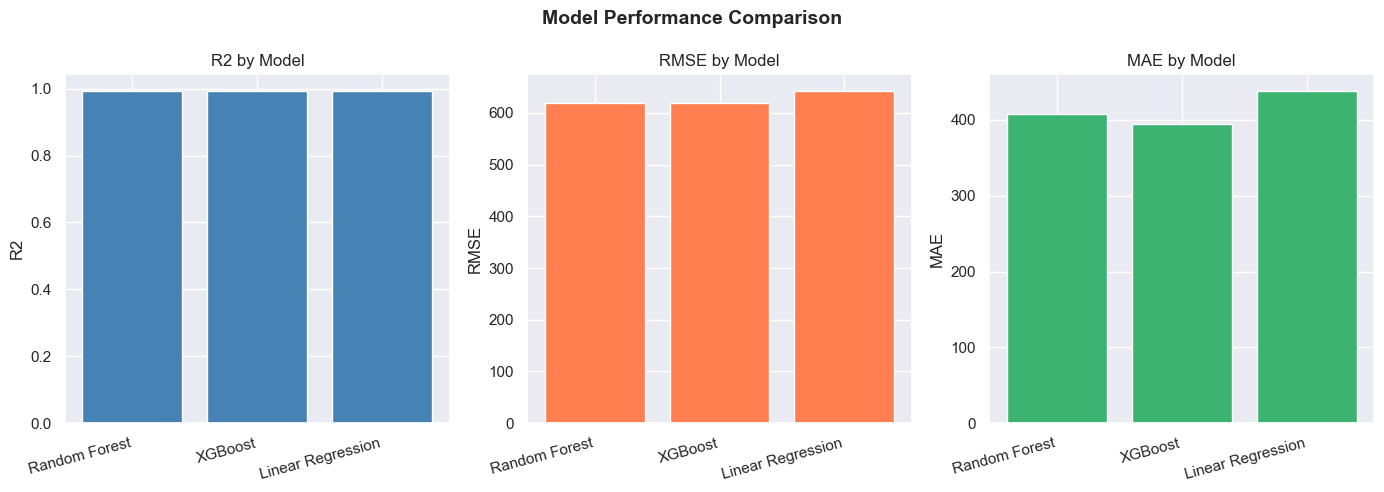

In [44]:
# ============================================================
# 7. PLOT — Model Comparison Bar Chart (fixed)
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metrics = ["R2", "RMSE", "MAE"]
colors  = ["steelblue", "coral", "mediumseagreen"]

for ax, metric, color in zip(axes, metrics, colors):
    models = results_df["Model"]
    values = results_df[metric]
    bars = ax.bar(range(len(models)), values, color=color, edgecolor="white")
    ax.set_title(f"{metric} by Model")
    ax.set_ylabel(metric)
    ax.set_xticks(range(len(models)))                        # ← fix
    ax.set_xticklabels(models, rotation=15, ha="right")     # ← fix

plt.suptitle("Model Performance Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("13_model_comparison.png", dpi=150)
plt.show()

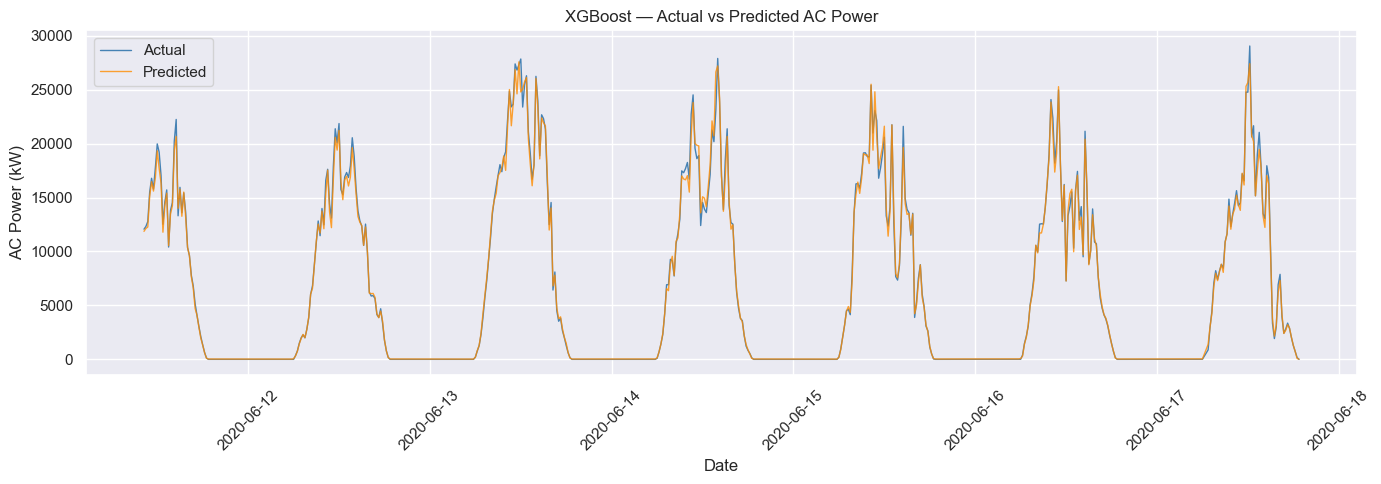

In [41]:
# ============================================================
# 8. PLOT — Actual vs Predicted (best model: XGBoost)
# ============================================================
test_dates = df["DATE_TIME"].iloc[split_idx:].reset_index(drop=True)

plt.figure(figsize=(14, 5))
plt.plot(test_dates, y_test.values,    label="Actual",    color="steelblue",  linewidth=1)
plt.plot(test_dates, y_pred_xgb,       label="Predicted", color="darkorange", linewidth=1, alpha=0.8)
plt.title("XGBoost — Actual vs Predicted AC Power")
plt.xlabel("Date")
plt.ylabel("AC Power (kW)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("14_actual_vs_predicted.png", dpi=150)
plt.show()

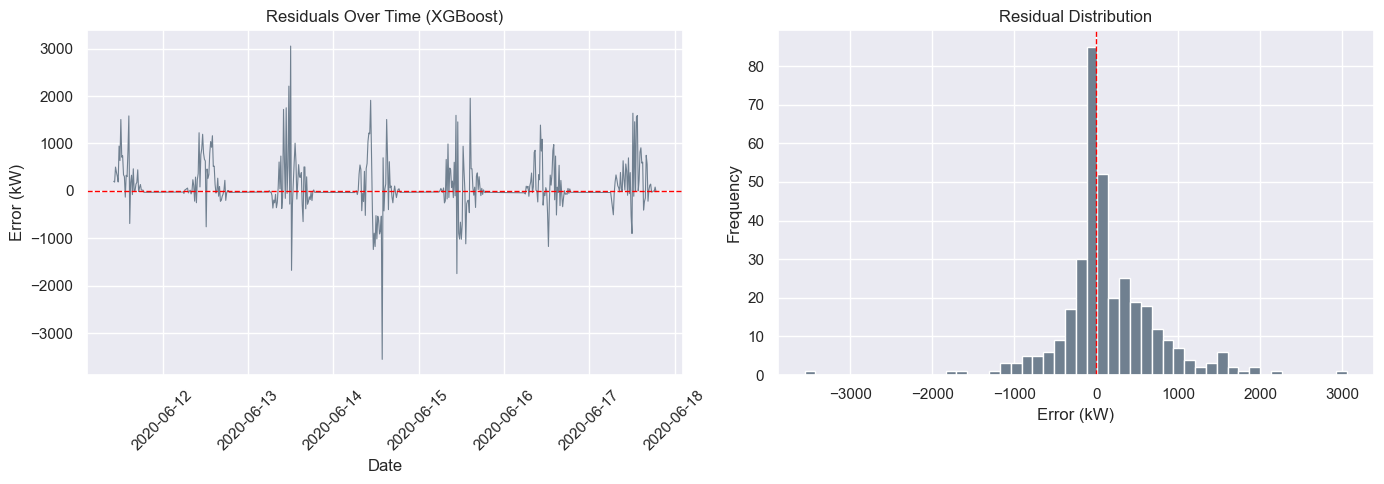

In [42]:
# ============================================================
# 9. PLOT — Residuals (Prediction Error)
# ============================================================
residuals = y_test.values - y_pred_xgb

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residual over time
axes[0].plot(test_dates, residuals, color="slategray", linewidth=0.8)
axes[0].axhline(0, color="red", linestyle="--", linewidth=1)
axes[0].set_title("Residuals Over Time (XGBoost)")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Error (kW)")
axes[0].tick_params(axis="x", rotation=45)

# Residual distribution
axes[1].hist(residuals, bins=50, color="slategray", edgecolor="white")
axes[1].axvline(0, color="red", linestyle="--", linewidth=1)
axes[1].set_title("Residual Distribution")
axes[1].set_xlabel("Error (kW)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.savefig("15_residuals.png", dpi=150)
plt.show()

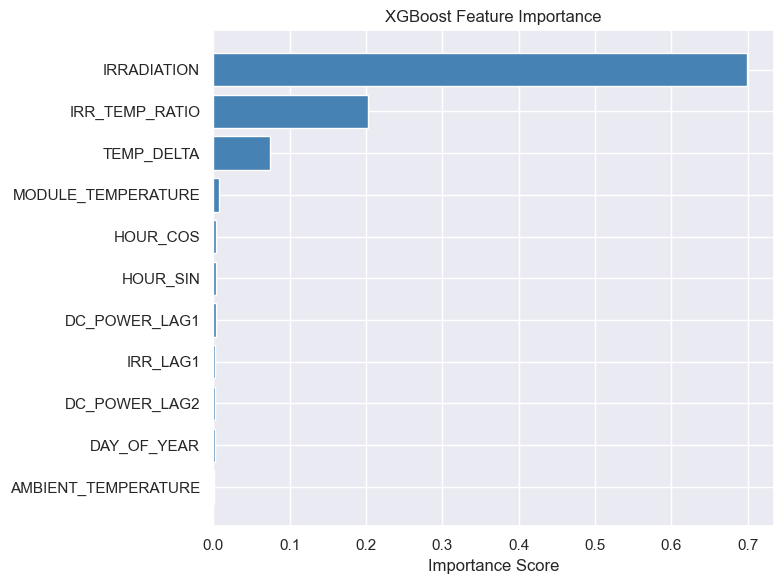

In [43]:
# ============================================================
# 10. PLOT — Feature Importance (XGBoost built-in)
# ============================================================
importance_df = pd.DataFrame({
    "Feature"   : FEATURES,
    "Importance": xgb.feature_importances_
}).sort_values("Importance", ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(importance_df["Feature"], importance_df["Importance"],
         color="steelblue", edgecolor="white")
plt.title("XGBoost Feature Importance")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig("16_feature_importance.png", dpi=150)
plt.show()

In [46]:
import subprocess

In [47]:
subprocess.run(["pip", "install", "shap"], check=True)


CompletedProcess(args=['pip', 'install', 'shap'], returncode=0)

In [49]:
# ============================================================
# Phase 4: SHAP Explainability + Anomaly Detection
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap

sns.set_theme(style="darkgrid")



In [50]:
# ============================================================
# 1. RELOAD DATA & MODELS
# ============================================================
df = pd.read_csv("plant1_processed.csv", parse_dates=["DATE_TIME"])
xgb = joblib.load("model_xgboost.pkl")
rf  = joblib.load("model_random_forest.pkl")

TARGET = "AC_POWER"
FEATURES = [
    "IRRADIATION",
    "AMBIENT_TEMPERATURE",
    "MODULE_TEMPERATURE",
    "IRR_TEMP_RATIO",
    "TEMP_DELTA",
    "HOUR_SIN",
    "HOUR_COS",
    "DAY_OF_YEAR",
    "DC_POWER_LAG1",
    "DC_POWER_LAG2",
    "IRR_LAG1"
]

X = df[FEATURES]
y = df[TARGET]

split_idx = int(len(df) * 0.80)
X_train   = X.iloc[:split_idx]
X_test    = X.iloc[split_idx:]
y_test    = y.iloc[split_idx:]

print("Data & models loaded.")

Data & models loaded.


In [51]:
# ============================================================
# 2. SHAP — XGBoost Explainer
# ============================================================
explainer   = shap.Explainer(xgb, X_train)
shap_values = explainer(X_test)

print("SHAP values computed.")
print("Shape:", shap_values.values.shape)

SHAP values computed.
Shape: (351, 11)


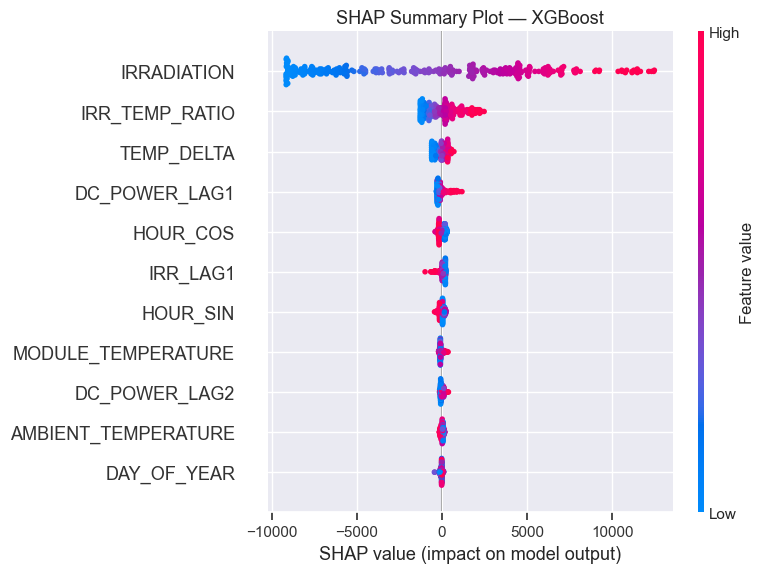

In [52]:
# ============================================================
# 3. PLOT — SHAP Summary (Beeswarm)
# Most important: shows WHICH features matter & HOW
# ============================================================
plt.figure()
shap.summary_plot(shap_values, X_test,
                  feature_names=FEATURES,
                  show=False)
plt.title("SHAP Summary Plot — XGBoost", fontsize=13)
plt.tight_layout()
plt.savefig("17_shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

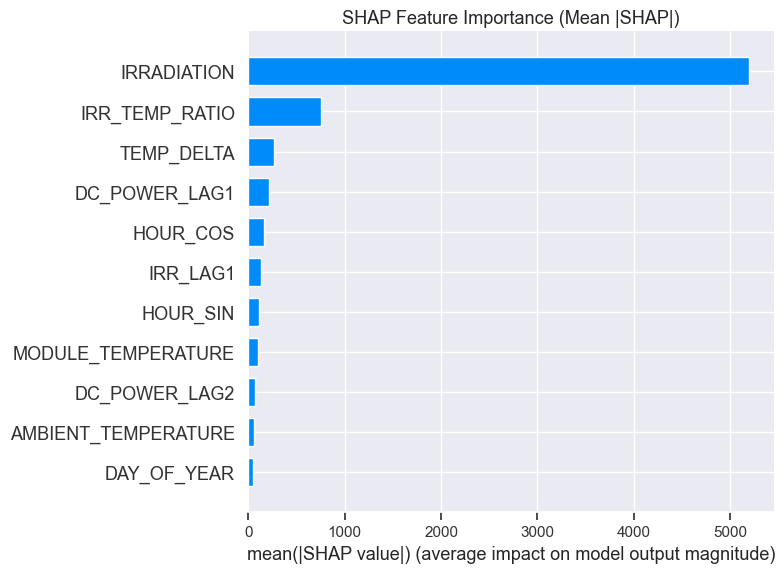

In [53]:
# ============================================================
# 4. PLOT — SHAP Bar (mean absolute impact per feature)
# ============================================================
plt.figure()
shap.summary_plot(shap_values, X_test,
                  feature_names=FEATURES,
                  plot_type="bar",
                  show=False)
plt.title("SHAP Feature Importance (Mean |SHAP|)", fontsize=13)
plt.tight_layout()
plt.savefig("18_shap_bar.png", dpi=150, bbox_inches="tight")
plt.show()

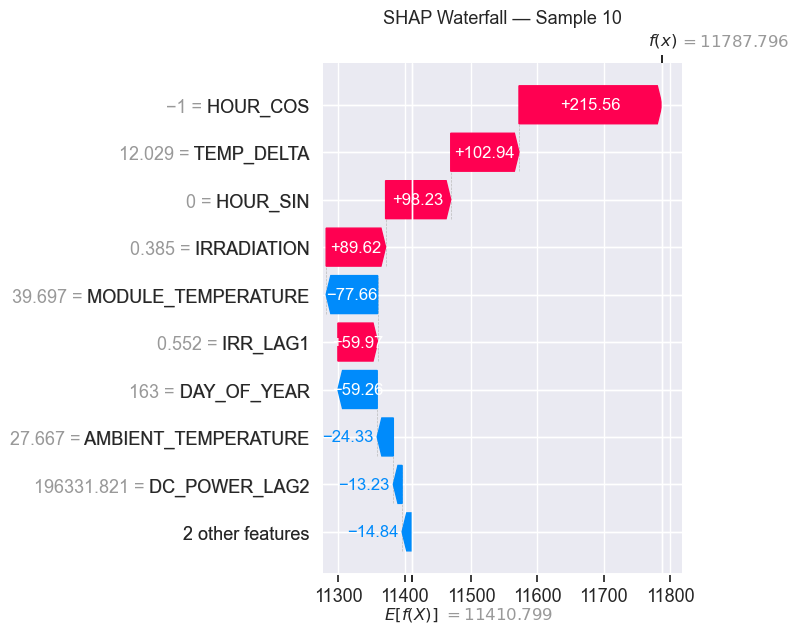

In [54]:
# ============================================================
# 5. PLOT — SHAP Waterfall (single prediction explained)
# Shows how each feature pushed one prediction up or down
# ============================================================
sample_idx = 10    # change to any row in test set

shap.waterfall_plot(shap_values[sample_idx], show=False)
plt.title(f"SHAP Waterfall — Sample {sample_idx}", fontsize=13)
plt.tight_layout()
plt.savefig("19_shap_waterfall.png", dpi=150, bbox_inches="tight")
plt.show()

In [55]:
# ============================================================
# 6. ANOMALY DETECTION
# Flag inverters performing significantly below expected output
# ============================================================

# Reload original generation data (pre-aggregation)
gen = pd.read_csv("Plant_1_Generation_Data.csv")
gen["DATE_TIME"] = pd.to_datetime(gen["DATE_TIME"], dayfirst=True)

# Compute daily yield per inverter
inv_daily = (gen.groupby(["SOURCE_KEY", gen["DATE_TIME"].dt.date])["DAILY_YIELD"]
               .max()
               .reset_index())
inv_daily.columns = ["SOURCE_KEY", "DATE", "DAILY_YIELD"]

# Overall daily average across all inverters
overall_avg = inv_daily.groupby("DATE")["DAILY_YIELD"].transform("mean")
inv_daily["EXPECTED_YIELD"] = overall_avg

# Performance ratio: actual vs expected
inv_daily["PERF_RATIO"] = inv_daily["DAILY_YIELD"] / inv_daily["EXPECTED_YIELD"]

# Flag anomalies: performance ratio below 0.80 (20% below average)
THRESHOLD = 0.80
inv_daily["ANOMALY"] = inv_daily["PERF_RATIO"] < THRESHOLD

anomalies = inv_daily[inv_daily["ANOMALY"]]
print(f"Total anomaly records  : {len(anomalies)}")
print(f"Inverters with anomalies: {anomalies['SOURCE_KEY'].nunique()}")
print("\nTop underperforming inverters:")
print(anomalies.groupby("SOURCE_KEY")["ANOMALY"].sum()
               .sort_values(ascending=False).head(10))

Total anomaly records  : 4
Inverters with anomalies: 2

Top underperforming inverters:
SOURCE_KEY
1BY6WEcLGh8j5v7    2
bvBOhCH3iADSZry    2
Name: ANOMALY, dtype: int64


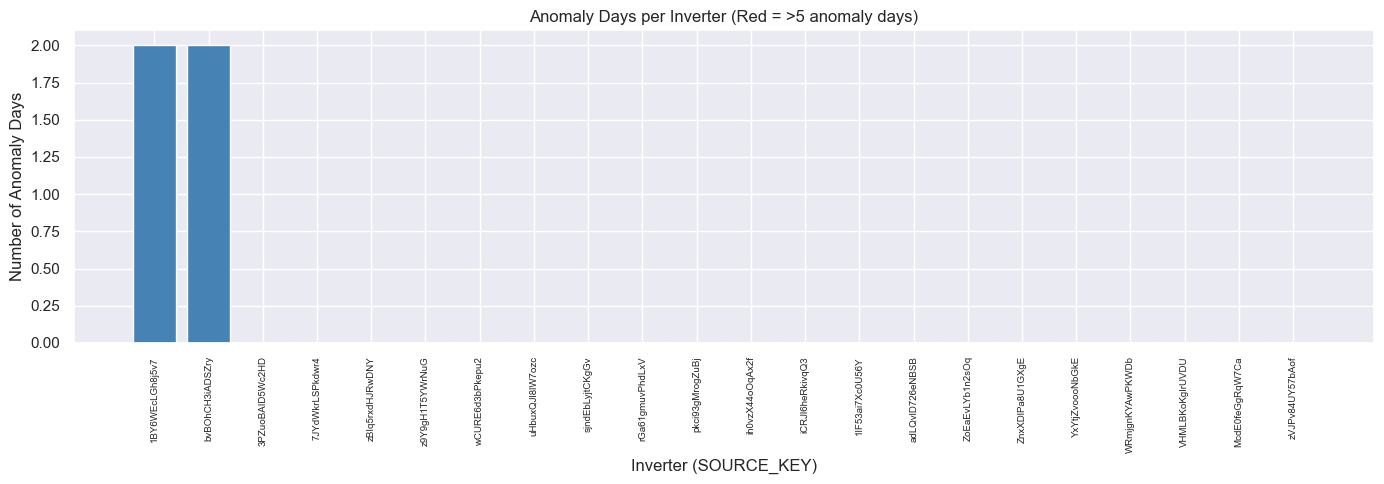

In [56]:
# ============================================================
# 7. PLOT — Anomaly Frequency per Inverter
# ============================================================
anomaly_count = (inv_daily.groupby("SOURCE_KEY")["ANOMALY"]
                           .sum()
                           .sort_values(ascending=False)
                           .reset_index())
anomaly_count.columns = ["SOURCE_KEY", "ANOMALY_DAYS"]

plt.figure(figsize=(14, 5))
bars = plt.bar(range(len(anomaly_count)),
               anomaly_count["ANOMALY_DAYS"],
               color=["crimson" if v > 5 else "steelblue"
                      for v in anomaly_count["ANOMALY_DAYS"]],
               edgecolor="white")
plt.xticks(range(len(anomaly_count)),
           anomaly_count["SOURCE_KEY"],
           rotation=90, fontsize=7)
plt.title("Anomaly Days per Inverter (Red = >5 anomaly days)")
plt.xlabel("Inverter (SOURCE_KEY)")
plt.ylabel("Number of Anomaly Days")
plt.tight_layout()
plt.savefig("20_anomaly_per_inverter.png", dpi=150)
plt.show()

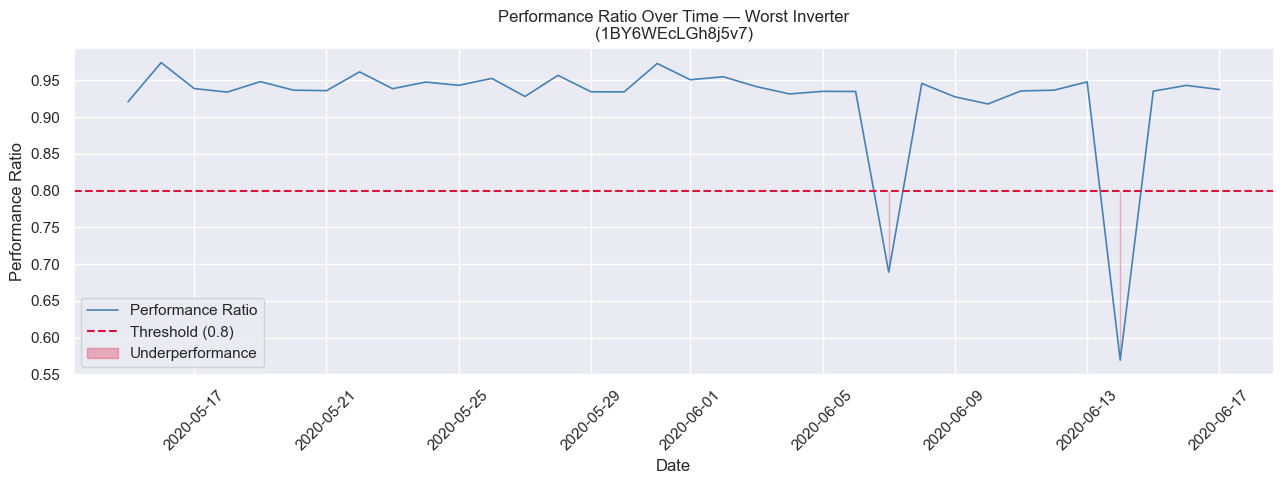

In [57]:
# ============================================================
# 8. PLOT — Performance Ratio Over Time (worst inverter)
# ============================================================
worst_inverter = anomaly_count.iloc[0]["SOURCE_KEY"]
inv_data = inv_daily[inv_daily["SOURCE_KEY"] == worst_inverter].copy()
inv_data = inv_data.sort_values("DATE")

plt.figure(figsize=(13, 5))
plt.plot(inv_data["DATE"], inv_data["PERF_RATIO"],
         color="steelblue", linewidth=1.2, label="Performance Ratio")
plt.axhline(THRESHOLD, color="crimson", linestyle="--",
            linewidth=1.5, label=f"Threshold ({THRESHOLD})")
plt.fill_between(inv_data["DATE"],
                 inv_data["PERF_RATIO"], THRESHOLD,
                 where=inv_data["PERF_RATIO"] < THRESHOLD,
                 color="crimson", alpha=0.3, label="Underperformance")
plt.title(f"Performance Ratio Over Time — Worst Inverter\n({worst_inverter})")
plt.xlabel("Date")
plt.ylabel("Performance Ratio")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("21_worst_inverter_performance.png", dpi=150)
plt.show()

In [58]:
# ============================================================
# 9. SAVE ANOMALY REPORT
# ============================================================
anomalies.to_csv("anomaly_report.csv", index=False)
print("Saved: anomaly_report.csv")
print(f"\nSummary:")
print(f"  Total inverters     : {inv_daily['SOURCE_KEY'].nunique()}")
print(f"  Anomalous inverters : {anomalies['SOURCE_KEY'].nunique()}")
print(f"  Total anomaly days  : {len(anomalies)}")

Saved: anomaly_report.csv

Summary:
  Total inverters     : 22
  Anomalous inverters : 2
  Total anomaly days  : 4
